# Network Intrusion Detection Using Deep Learning


### load libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### load the dataset and Exploration

In [ ]:
df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.head()


In [ ]:
df.shape
# display number of rows and columns

(9537, 11)

In [ ]:
df.info()
# display general informatin about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [ ]:
df.describe()
# display descriptive statistics about numerical columns

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [ ]:
#حذف session_id لأنه غير مفيد
df = df.drop(columns=['session_id'], errors='ignore')


In [ ]:
df.isnull().sum()
#check for missing values at each column

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [ ]:
df['encryption_used'] = df['encryption_used'].fillna(
    df['encryption_used'].mode()[0]
)
#The missing values in the “encryption_used” feature were handled by
#replacing them with the most frequent value (mode),
# since the feature is categorical.


In [ ]:
df.isnull().sum()
#check for missing values at each column

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [ ]:
df.duplicated().sum()
# counts the number of duplicate rows in the data

np.int64(0)

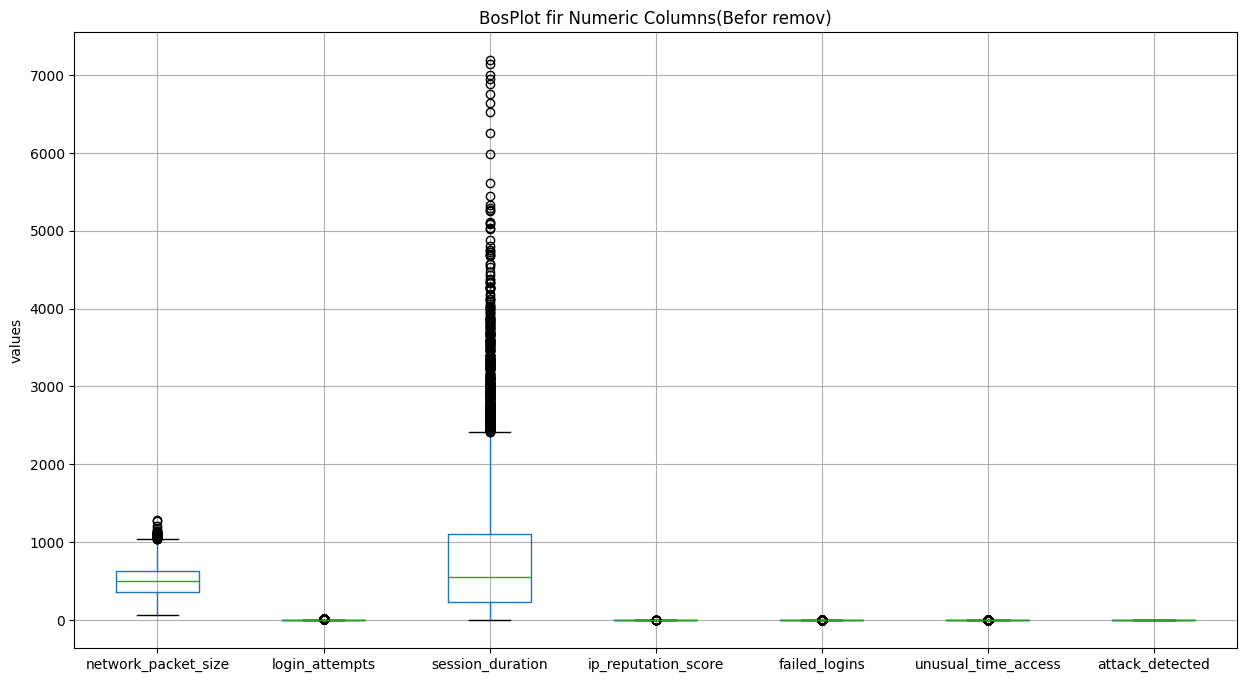

In [ ]:
# use BoxPlot to visually derect outliers values
num_columns = df.select_dtypes(include=['float64' , 'int64' , 'int32']).columns

plt.figure(figsize=(15,8))
df[num_columns].boxplot()
plt.title("BosPlot fir Numeric Columns(Befor remov)")
plt.ylabel("values")
plt.grid(True)
plt.show()

In [ ]:
X = df.drop(columns=['attack_detected'])
Y = df['attack_detected']

In [ ]:
X = pd.get_dummies(X, drop_first=True)
#لازم نحول كل الأعمدة الي ارقام حتى يقدر النموزج يتعامل معها

In [ ]:
np.isfinite(X).all()
# ensure that all values are numerical and valid for calculation

,0
network_packet_size,True
login_attempts,True
session_duration,True
ip_reputation_score,True
failed_logins,True
unusual_time_access,True
protocol_type_TCP,True
protocol_type_UDP,True
encryption_used_DES,True
browser_type_Edge,True


### Train / Test
#### divides the data into training and testing groups

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

### **Normalization**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


#نضمن كل القيم بين 0 و 1

In [ ]:
# عرض أبعاد بيانات التدريب والاختبار
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7629, 13)
X_test shape: (1908, 13)
y_train shape: (7629,)
y_test shape: (1908,)


### **Reshape Data for CNN**

In [ ]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")



In [ ]:

X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# التأكيد
print("X_train_cnn dtype:", X_train_cnn.dtype)
print("X_train_cnn shape:", X_train_cnn.shape)


X_train_cnn dtype: float32
X_train_cnn shape: (7629, 13, 1)


### **Build CNN Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
model_cnn = Sequential()
model_cnn.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1],1)))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dropout(0.3))
model_cnn.add(Dense(1, activation='sigmoid'))
model_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,497 (41.00 KB)

 Trainable params: 10,497 (41.00 KB)

 Non-trainable params: 0 (0.00 B)

### **Train the Model**

In [ ]:
print(X_train_cnn.dtype, X_train_cnn.shape)
print(y_train.dtype, y_train.shape)


float32 (7629, 13, 1)
int64 (7629,)


In [ ]:

print("y_train type:", y_train.dtype)
print("y_test type:", y_test.dtype)
print("First 10 labels in y_train:", y_train[:10])


y_train type: int64
y_test type: int64
First 10 labels in y_train: 3334    0
4684    0
6385    0
7288    1
8466    0
3271    1
6027    0
9024    0
5764    0
584     0
Name: attack_detected, dtype: int64


In [ ]:
# تدريب نموذج CNN
history_cnn = model_cnn.fit(
    X_train_cnn,        # بيانات التدريب بعد عمل reshape
    y_train,            # التصنيفات (Labels)
    epochs=10,          # عدد مرات المرور على البيانات بالكامل
    batch_size=128,     # عدد العينات لكل تحديث للوزن
    validation_split=0.1,  # نسبة 10% من بيانات التدريب للـ validation
    verbose=1           # يعرض تقدم التدريب خطوة بخطوة
)


Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.5695 - loss: 0.6806 - val_accuracy: 0.7025 - val_loss: 0.6335
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6924 - loss: 0.6160 - val_accuracy: 0.7484 - val_loss: 0.5747
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7461 - loss: 0.5597 - val_accuracy: 0.7798 - val_loss: 0.5291
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7690 - loss: 0.5176 - val_accuracy: 0.7811 - val_loss: 0.4947
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7912 - loss: 0.4863 - val_accuracy: 0.8087 - val_loss: 0.4700
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8048 - loss: 0.4687 - val_accuracy: 0.8204 - val_loss: 0.4494
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8189 - loss: 0.4470 - val_accuracy: 0.8309 - val_loss: 0.4318
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8264 - loss: 0.4359 - val_accuracy: 0.8336 - val_loss

In [ ]:
print(Y.value_counts())
print(Y.value_counts(normalize=True))


attack_detected
0    5273
1    4264
Name: count, dtype: int64
attack_detected
0    0.552899
1    0.447101
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# التنبؤ
y_pred_proba = model_cnn.predict(X_test_cnn).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

# التقييم
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print("Performance Evaluation Results")
print("------------------------------")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Performance Evaluation Results
------------------------------
Accuracy  : 0.8322851153039832
Precision : 0.8867924528301887
Recall    : 0.716295427901524
F1-score  : 0.7924773022049286

Confusion Matrix:
[[977  78]
 [242 611]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1055
           1       0.89      0.72      0.79       853

    accuracy                           0.83      1908
   macro avg       0.84      0.82      0.83      1908
weighted avg       0.84      0.83      0.83      1908



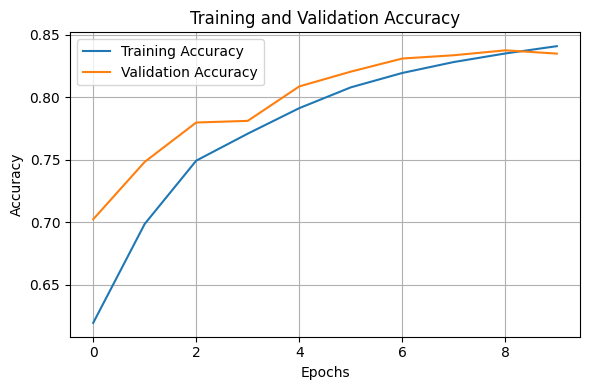

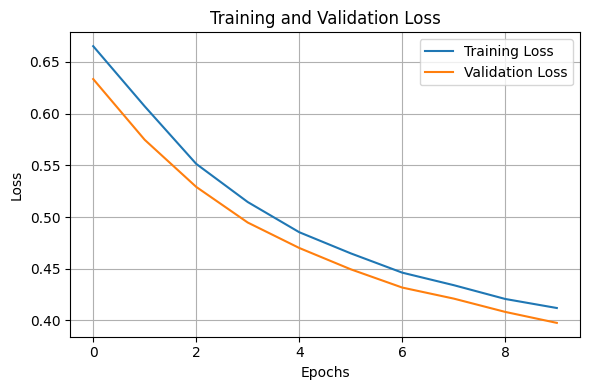

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


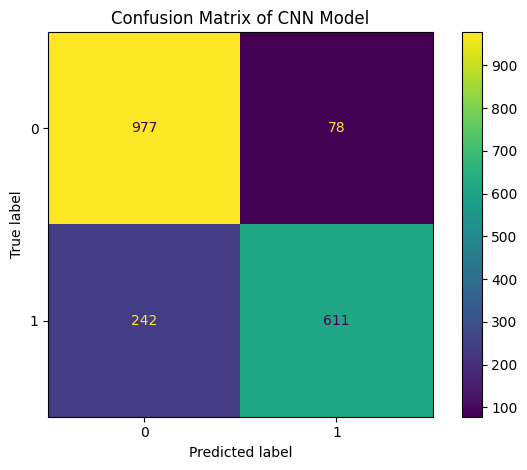

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===============================
# Training & Validation Accuracy
# ===============================
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# Training & Validation Loss
# ===============================
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# Confusion Matrix
# ===============================
y_pred_proba = model_cnn.predict(X_test_cnn)
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix of CNN Model")
plt.tight_layout()
plt.show()

### Histogram

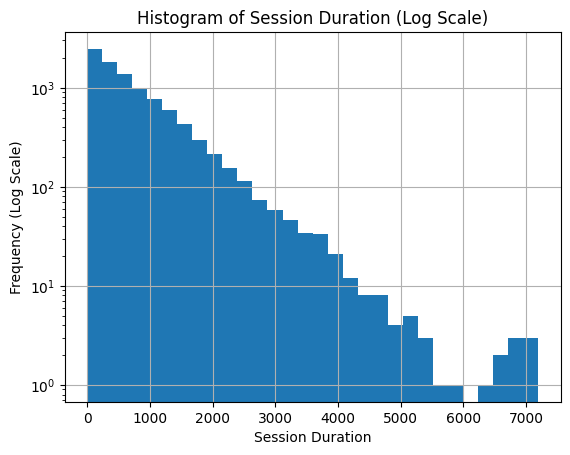

In [ ]:
plt.figure()
plt.hist(df['session_duration'], bins=30)  # استبدال flow_duration بعمود موجود
plt.yscale('log')
plt.title("Histogram of Session Duration (Log Scale)")  # تعديل العنوان
plt.xlabel("Session Duration")  # تعديل تسمية المحور
plt.ylabel("Frequency (Log Scale)")
plt.grid(True)
plt.show()


### Bar Chart

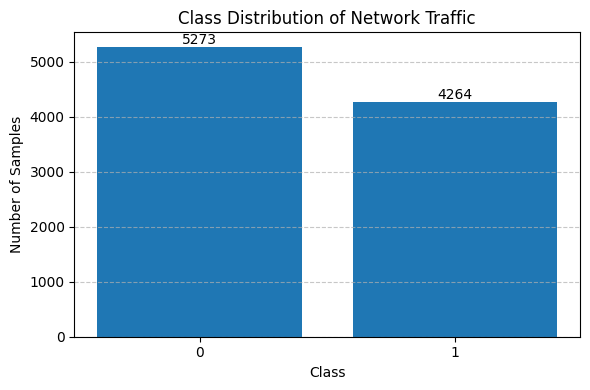

In [ ]:
counts = df['attack_detected'].value_counts()  # استخدام العمود الصحيح

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)

plt.title("Class Distribution of Network Traffic")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

# إظهار الأرقام فوق الأعمدة
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Scatter Plot

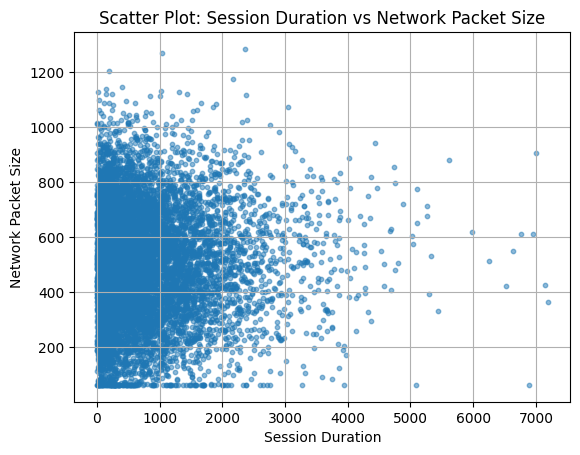

In [ ]:
plt.figure()
plt.scatter(df['session_duration'], df['network_packet_size'], s=10, alpha=0.5)
plt.title("Scatter Plot: Session Duration vs Network Packet Size")
plt.xlabel("Session Duration")
plt.ylabel("Network Packet Size")
plt.grid(True)
plt.show()
